# Sharadar v11 — Walk-Forward Results

Random forest, cross-sectional forward-return regression on the Sharadar panel.
**Frozen configuration:** RF, expanding train window, **`H=40` label**, **top 1%**,
`monthly_tranche2` (~42-session hold), `label=cz`, ADV ≥ \$25M, 33 ranked features + 3 market-wide,
200 trees, 6 folds, 63-session embargo.

Each piece was settled by experiment rather than assumed:

- **Hold length ~42 sessions.** Tested against a ~21-session hold at the same book size: 42 days won
  by 2.8pp of CAGR with half the turnover, so the ranking persists beyond the forecast window.
- **Label horizon H=40, matched to the hold.** Tested against H=20 on the same 42-session hold:
  +15.7% vs +14.0% CAGR, Sharpe 0.49 vs 0.44, and a drawdown 8pp shallower.
- **Threshold top 1%.** The traded slice of the ranking.
- **80/20 hedge, no 60/40.** The Monte Carlo showed the 60/40 was indistinguishable from owning SPY.

Those comparison runs are not reproduced here; the configuration below is the one they selected.

Out-of-sample window **2006-03-17 → 2022-12-30** (4,517,358 stock-day predictions).
Everything from 2023-01-01 onward is untouched holdout and appears nowhere in this notebook.

**What's in here**

1. How the walk-forward folds are laid out
2. Gate 1 — rank-IC and its progression across folds
3. Gate 2 — the decile ladder, and how return per trade responds to the selection threshold
4. The final fold on its own (D1→D10, gross beside net)
5. What the calibration slope of 0.426 actually means
6. The book table — continuous, monthly tranche-2, hedges, benchmarks
7. Equity curves vs SPY
8. Alpha and beta (CAPM)

In [1]:
# ── run from the repo root regardless of where the kernel started ─────────────────────────────
# Notebooks live in notebooks/ but every data path is relative to the repo root, and sh_*.py must be
# importable. Doing this here keeps every other cell location-agnostic.
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

FIGDIR = os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)


def save(name, show=True, dpi=200):
    """Write the current figure to report/figures/<name>.png, then show it."""
    import matplotlib.pyplot as _plt
    f = _plt.gcf()
    path = os.path.join(FIGDIR, f"{name}.png")
    f.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  → {path}")
    _plt.show() if show else _plt.close(f)


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

DATA   = "data_sharadar"
# FROZEN CONFIGURATION (see §13 for how it was chosen):
#   H=40 label  -- the forecast horizon matches the ~42-session hold
#   top 1%      -- the traded threshold; supplies ~11 candidates per rebalance day
#   monthly_tranche2, book target 30, borrow 8%/yr
# The 60/40 hedge is not carried: the Monte Carlo showed it was indistinguishable from owning SPY.
SIGNAL = f"{DATA}/sh_oos_H40_cz_adv25.parquet"
BOOKS  = f"{DATA}/sh_books_h40_top1.parquet"
MET    = f"{DATA}/sh_books_h40_top1_metrics.parquet"
H      = 40
# House risk-free rate. Sharpe and Sortino below are EXCESS of this, not raw.
RF_ANNUAL = 0.0375
RF_DAILY  = RF_ANNUAL / 252

# ── plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})

INK   = "#1f2933"
BLUE  = "#2b6cb0"
TEAL  = "#0f8b8d"
AMBER = "#d98324"
RED   = "#c0392b"
GREY  = "#9aa5b1"
GREEN = "#2e7d5b"

def style(ax, ygrid=True, xgrid=False):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

pct  = FuncFormatter(lambda v, _: f"{v:.0%}")
pct1 = FuncFormatter(lambda v, _: f"{v:+.1f}%")
# ── autocorrelation-corrected t ────────────────────────────────────────────────────────────────
# The naive t = mean / (sd/sqrt(n)) assumes independent observations. Daily rank-IC is NOT
# independent: every day is scored against a 40-day FORWARD return, so consecutive days overlap in
# 39 of their 40 days and are measuring almost the same stretch of market. Measured lag-1
# autocorrelation is +0.90, and it reaches zero at lag 40 -- the label horizon, which confirms the
# overlap is the cause rather than some market property.
#
# Newey-West with a Bartlett kernel rescales the standard error by the autocovariance structure.
# n_eff is the implied independent sample size.
NW_LAG = 40   # = H. Was 20 while the label was H=20; at H=40 that under-corrected (IC autocorr is
              # still +0.25 at lag 20), which inflated every t in this notebook.


def nw_t(x, lag=NW_LAG):
    """Returns (t_naive, t_newey_west, n_eff) for the mean of series x."""
    import numpy as _np
    x = _np.asarray(x, dtype=float)
    x = x[_np.isfinite(x)]
    n = len(x)
    m = x.mean()
    c = x - m
    g0 = c @ c / n
    v = g0 + 2.0 * sum((1.0 - k / (lag + 1.0)) * (c[:-k] @ c[k:]) / n
                       for k in range(1, lag + 1))
    t_naive = m / (x.std(ddof=1) / _np.sqrt(n))
    t_nw = m / _np.sqrt(v / n)
    return t_naive, t_nw, n * g0 / v

print("ready")

ready


---
## 1. Walk-forward folds

The model is never fit and evaluated on the same period. The eligible history is split into six
consecutive **test** windows; for each one the forest is refit from scratch on data that ends well
before the test window opens, then predicts every eligible stock-day inside it.

Three things make this honest:

**Expanding train window.** Training always starts at `1999-01-04`, the first date any ticker
clears the eligibility bar (ADV ≥ \$25M, price ≥ \$5, and at least 252 bars of history — which is
why the tradeable universe starts a year after the raw panel's 1998 origin). Only the train *end*
advances. The alternative, a fixed-length rolling window, was tested and lost decisively:
rank-IC +0.0198 against +0.0367.

**A 63-session embargo.** The band between train end and test start is thrown away. It has to be:
the label is a 20-day forward return, so a training row dated three weeks before the test window
carries a label measured from prices *inside* it. Training on that row shows the forest the very
returns it is about to be graded on. `H=20` sets the minimum gap; 63 sessions is 3× that, buffering
the trailing windows the features themselves use.

**A train-only reserve.** The first 30% of eligible dates — `1999-01-04` through `2006-03-16`,
1,811 sessions — is never tested on, so that fold 0 has real history behind it. The cost is that
the dot-com bust sits in training but has never appeared in an out-of-sample number.

Each fold is an independent fit. The six test windows are contiguous, non-overlapping, and stitched
end to end into the single OOS record everything below is computed from.

In [2]:
TRAIN_START = pd.Timestamp("1999-01-04")
EMBARGO     = 63

# Train cut per fold: training uses dates STRICTLY BEFORE this. Reproduced from sh_regress.run(),
# which takes the 63rd eligible session preceding each test window's first date.
CUTS = ["2005-12-14", "2008-10-03", "2011-07-22", "2014-05-13", "2017-03-01", "2019-12-16"]

# `sig` (ewm volatility) is loaded for section 12, which tests whether the daily selection bar
# is really a volatility-regime proxy.
oos = pd.read_parquet(SIGNAL,
                      columns=["date", "fwd", "net", "cost", "pred", "y", "fold", "sig"])
oos = oos[np.isfinite(oos.fwd) & np.isfinite(oos.pred)]

fw = oos.groupby("fold")["date"].agg(["min", "max", "size"])
folds = pd.DataFrame({
    "fold": fw.index,
    "train_start": TRAIN_START,
    "train_end_excl": pd.to_datetime(CUTS),
    "test_start": fw["min"].values,
    "test_end": fw["max"].values,
    "test_rows": fw["size"].values,
})
folds["train_yrs"] = ((folds.train_end_excl - folds.train_start).dt.days / 365.25).round(1)

show = folds.copy()
for c in ["train_start", "train_end_excl", "test_start", "test_end"]:
    show[c] = show[c].dt.date
show["test_rows"] = show["test_rows"].map("{:,}".format)
print(f"OOS  {oos.date.min().date()} .. {oos.date.max().date()}   {len(oos):,} rows"
      f"   {oos.date.nunique():,} dates\n")
print(show.to_string(index=False))

OOS  2006-03-17 .. 2022-12-30   4,517,358 rows   4,228 dates

 fold train_start train_end_excl test_start   test_end test_rows  train_yrs
    0  1999-01-04     2005-12-14 2006-03-17 2009-01-02   661,496        6.9
    1  1999-01-04     2008-10-03 2009-01-05 2011-10-19   626,494        9.7
    2  1999-01-04     2011-07-22 2011-10-20 2014-08-11   685,183       12.5
    3  1999-01-04     2014-05-13 2014-08-12 2017-05-30   777,398       15.4
    4  1999-01-04     2017-03-01 2017-05-31 2020-03-17   821,000       18.2
    5  1999-01-04     2019-12-16 2020-03-18 2022-12-30   945,787       20.9


  → report/figures/results_01_walkforward_folds.png


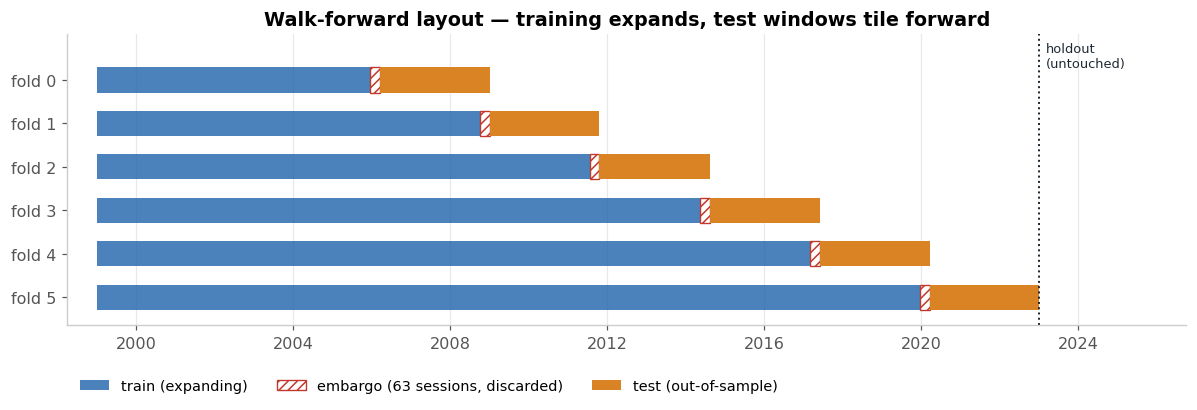

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.9))
for _, r in folds.iterrows():
    y = r.fold
    ax.barh(y, r.train_end_excl - r.train_start, left=r.train_start,
            height=0.58, color=BLUE, alpha=.85,
            label="train (expanding)" if y == 0 else None)
    ax.barh(y, r.test_start - r.train_end_excl, left=r.train_end_excl,
            height=0.58, color="#ffffff", edgecolor=RED, hatch="////", linewidth=.9,
            label=f"embargo ({EMBARGO} sessions, discarded)" if y == 0 else None)
    ax.barh(y, r.test_end - r.test_start, left=r.test_start,
            height=0.58, color=AMBER, label="test (out-of-sample)" if y == 0 else None)

ax.set_yticks(folds.fold, [f"fold {i}" for i in folds.fold])
ax.invert_yaxis()
ax.set_ylim(5.65, -1.05)
ax.set_xlim(pd.Timestamp("1998-04-01"), pd.Timestamp("2026-10-01"))
ax.set_title("Walk-forward layout — training expands, test windows tile forward")
ax.set_xlabel("")
ax.axvline(pd.Timestamp("2023-01-01"), color=INK, ls=":", lw=1.3)
ax.text(pd.Timestamp("2023-03-01"), -0.55, "holdout\n(untouched)", fontsize=8.5,
        color=INK, va="center", ha="left")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.14), ncol=3)
style(ax, ygrid=False, xgrid=True)
plt.tight_layout(); save("results_01_walkforward_folds")

---
## 2. Gate 1 — rank-IC

**The question.** Does the model's *ordering* of stocks match the order they actually delivered?

Each trading day we rank every eligible name by predicted score, rank the same names by realized
20-day forward return, and take the Spearman correlation between the two. That gives one number per
day. The headline is the **mean across days**. Averaging per-day rather than pooling all rows
matters — pooling lets a handful of enormous days carry the result.

**On the t-statistic.** `sh_gates.py` computes it as `mean / (sd/√n)` with n = 4,228 days, which
assumes every day is an independent observation. They are not: each day is scored against a **40-day**
forward return, so consecutive days overlap in 39 of their 40 days and are measuring almost the same
stretch of market.

The autocorrelation below is the proof, and it is a cleaner demonstration at H=40 than it was at
H=20: lag-1 is +0.90, it is still +0.25 at lag 20, and it only reaches zero around **lag 40** — exactly
the label horizon. The zero-crossing tracks H, which is what you would expect if overlapping windows
are the cause and nothing else is.

Because the dependence now runs twice as far, the naive t is overstated by more: **24.0 naive against
6.60 corrected**, a factor of 3.6, with an effective sample of 319 independent observations rather
than 4,228. **Quote 6.6.**

A rank-IC of +0.037 sounds small and is entirely normal for cross-sectional equity forecasting. It
is an average over ~1,000 names per day; the payoff shows up at the tail, which is section 3.

In [4]:
g = oos.groupby("date", sort=True)
oos["rp"] = g["pred"].rank(pct=True)     # predicted rank within the day
oos["rf"] = g["fwd"].rank(pct=True)      # realized rank within the day
oos["dec"] = np.minimum((oos["rp"] * 10).astype(np.int8), 9)

def per_date_ic(d):
    # Vectorised Spearman per date: Pearson correlation on within-day percentile ranks.
    d = d.assign(_xy=d.rp * d.rf, _x2=d.rp ** 2, _y2=d.rf ** 2)
    gg = d.groupby("date", sort=True)
    n = gg.size().to_numpy(float)
    sx, sy = gg["rp"].sum().to_numpy(), gg["rf"].sum().to_numpy()
    sxy, sx2, sy2 = gg["_xy"].sum().to_numpy(), gg["_x2"].sum().to_numpy(), gg["_y2"].sum().to_numpy()
    num = sxy - sx * sy / n
    den = np.sqrt(np.maximum(sx2 - sx * sx / n, 0) * np.maximum(sy2 - sy * sy / n, 0))
    return pd.Series(num / np.where(den > 0, den, np.nan),
                     index=gg.size().index, name="ic").dropna()

ic_daily = per_date_ic(oos)
IC = ic_daily.mean()
T_NAIVE, T_ADJ, N_EFF = nw_t(ic_daily)

print(f"rank-IC  {IC:+.4f}    ({len(ic_daily):,} days, day-to-day sd {ic_daily.std(ddof=1):.4f})")
print(f"share of days positive: {(ic_daily > 0).mean():.1%}")
print(f"distribution: " + " | ".join(
    f"{p}% {np.percentile(ic_daily, p):+.3f}" for p in (5, 25, 50, 75, 95)))
print(f"\n  t naive            {T_NAIVE:6.1f}   <- what sh_gates.py prints; assumes 4,228 "
      f"independent days")
print(f"  t adjusted (NW-40) {T_ADJ:6.2f}   <- the honest figure, n_eff = {N_EFF:,.0f}")
print(f"  overstatement      {T_NAIVE/T_ADJ:6.2f}x")

print("\nautocorrelation of the daily IC series (decays to zero at the 20-day hold length):")
a = ic_daily.to_numpy()
print("  " + "  ".join(f"lag {k}: {np.corrcoef(a[:-k], a[k:])[0,1]:+.3f}"
                       for k in (1, 5, 10, 19, 20, 40)))

rank-IC  +0.0487    (4,228 days, day-to-day sd 0.1319)
share of days positive: 65.9%
distribution: 5% -0.152 | 25% -0.028 | 50% +0.041 | 75% +0.126 | 95% +0.274

  t naive              24.0   <- what sh_gates.py prints; assumes 4,228 independent days
  t adjusted (NW-40)   5.58   <- the honest figure, n_eff = 228
  overstatement        4.30x

autocorrelation of the daily IC series (decays to zero at the 20-day hold length):
  lag 1: +0.896  lag 5: +0.650  lag 10: +0.523  lag 19: +0.273  lag 20: +0.250  lag 40: -0.030


### Two different fold-level statistics

The run log reports per-fold IC as a *single pooled* Spearman over every row in the fold, ignoring
the day boundary. That statistic reads much lower than the headline and shows one fold as slightly
negative. It is not comparable to the headline — pooling across dates lets differences in the
overall return level between days enter the correlation as noise, and fold 0 spans the financial
crisis, where that noise is largest.

Below, both are computed. The **mean of daily IC within each fold** is the one that reconciles with
the headline, and on that basis every fold is positive.

In [5]:
rows = []
for f, d in oos.groupby("fold"):
    daily = per_date_ic(d)
    rows.append({
        "fold": int(f),
        "test_start": d.date.min().date(), "test_end": d.date.max().date(),
        "days": len(daily),
        "IC (mean of daily)": round(daily.mean(), 4),
        # ⚠️ t_naive assumes 705 independent days; it is here only to show the size of the
        # correction. A fold is ~705/40 ~= 17 independent observations, far too few to clear a
        # significance bar on its own -- the evidence is the pooled series, not any single fold.
        "t_naive": round(nw_t(daily)[0], 1),
        "t_NW": round(nw_t(daily)[1], 2),
        "IC (pooled vs label y)": round(d["pred"].corr(d["y"], method="spearman"), 4),
        "days > 0": f"{(daily > 0).mean():.0%}",
    })
by_fold = pd.DataFrame(rows)
print(by_fold.to_string(index=False))
print(f"\nmean of the six fold ICs: {by_fold['IC (mean of daily)'].mean():+.4f}"
      f"   vs pooled-statistic mean {by_fold['IC (pooled vs label y)'].mean():+.4f}")

 fold test_start   test_end  days  IC (mean of daily)  t_naive  t_NW  IC (pooled vs label y) days > 0
    0 2006-03-17 2009-01-02   705              0.0417      7.5  1.76                  0.0512      61%
    1 2009-01-05 2011-10-19   705              0.0692     12.2  2.93                  0.0709      70%
    2 2011-10-20 2014-08-11   705              0.0219      5.4  1.20                  0.0163      67%
    3 2014-08-12 2017-05-30   705              0.0380      7.9  1.69                  0.0362      59%
    4 2017-05-31 2020-03-17   704              0.0293      7.6  1.88                  0.0278      60%
    5 2020-03-18 2022-12-30   704              0.0922     18.2  5.02                  0.1041      77%

mean of the six fold ICs: +0.0487   vs pooled-statistic mean +0.0511


  → report/figures/results_02_rank_ic.png


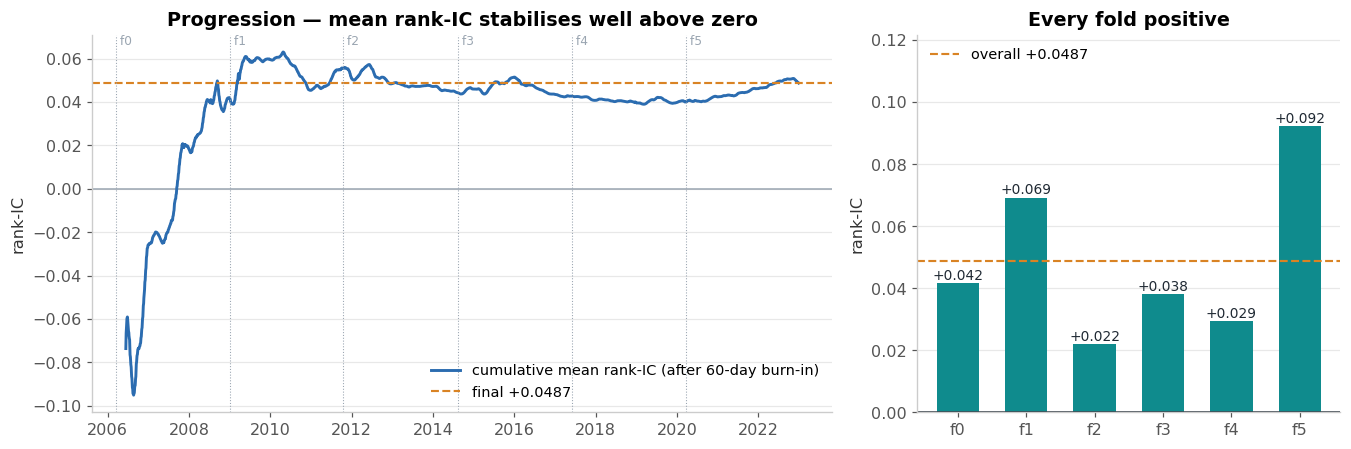

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.2),
                             gridspec_kw={"width_ratios": [1.75, 1]})

# ── cumulative mean IC through time ──
# 60-day burn-in: the first few weeks of an expanding mean swing wildly on a handful of days and
# would otherwise compress the scale for the remaining 17 years.
BURN = 60
run_mean = ic_daily.expanding().mean().iloc[BURN:]
a1.axhline(0, color=GREY, lw=1)
a1.plot(run_mean.index, run_mean.values, color=BLUE, lw=1.9,
        label=f"cumulative mean rank-IC (after {BURN}-day burn-in)")
a1.axhline(IC, color=AMBER, ls="--", lw=1.4, label=f"final {IC:+.4f}")
for _, r in folds.iterrows():
    a1.axvline(r.test_start, color=GREY, lw=.7, ls=":")
    a1.text(r.test_start, a1.get_ylim()[1], f" f{r.fold}", fontsize=8, color=GREY, va="top")
a1.set_title("Progression — mean rank-IC stabilises well above zero")
a1.set_ylabel("rank-IC"); a1.legend(loc="lower right")
style(a1)

# ── by fold ──
bars = a2.bar(by_fold.fold, by_fold["IC (mean of daily)"], color=TEAL, width=.62)
a2.axhline(IC, color=AMBER, ls="--", lw=1.4, label=f"overall {IC:+.4f}")
a2.axhline(0, color=INK, lw=1)
# No per-fold t on the bars. A fold holds ~17 independent observations at H=40, so a per-fold t is
# not a meaningful significance test -- printing one invites exactly the wrong reading. The chart's
# claim is consistency of SIGN; significance is argued on the pooled series.
for b, v in zip(bars, by_fold["IC (mean of daily)"]):
    a2.text(b.get_x() + b.get_width() / 2, v + .0012, f"{v:+.3f}",
            ha="center", fontsize=9, color=INK)
a2.set_xticks(by_fold.fold, [f"f{i}" for i in by_fold.fold])
a2.set_ylim(0, max(by_fold["IC (mean of daily)"]) * 1.32)
a2.set_title("Every fold positive"); a2.set_ylabel("rank-IC"); a2.legend(loc="upper left")
style(a2)
plt.tight_layout(); save("results_02_rank_ic")

---
## 3. Gate 2 — the decile ladder, and the selection threshold

**The question.** Does the whole return distribution shift right as the score rises, or is the
average being carried by a few outliers?

Every day, eligible names are sorted by predicted score into ten buckets — **per date, never
pooled**, because pooling lets a high-volatility era dominate the top bucket and manufactures a
spread that is really a time effect. D1 is the lowest-scored decile, D10 the highest.

`gross` is the executable forward return: buy the open of t+1, exit the close of t+20.
`net` subtracts the calibrated round-trip cost (spread + impact), charged on entry. **The model
never trains on net** — cost correlates with volatility, so a cost-adjusted label would inject an
anti-volatility tilt. Cost enters only here, at evaluation.

The second chart pushes past the deciles. D10 is the top 10%, but the book trades the top 1%, so
what matters is whether return per trade keeps climbing as the threshold tightens — and whether
rising cost eats the gain.

In [7]:
dec = oos.groupby("dec").agg(gross=("fwd", "mean"), net=("net", "mean"),
                             cost=("cost", "mean"), hit=("net", lambda s: (s > 0).mean()),
                             n=("net", "size"))
dec[["gross", "net", "hit"]] *= 100
dec["cost"] *= 1e4                      # fraction -> basis points
dec.index = [f"D{i+1}" for i in dec.index]
print(f"{H}-day return per trade by predicted decile\n")
print(dec.assign(gross=dec.gross.map("{:+.2f}%".format), net=dec.net.map("{:+.2f}%".format),
                 cost=dec.cost.map("{:.0f}bp".format), hit=dec.hit.map("{:.1f}%".format),
                 n=dec.n.map("{:,}".format))
        .rename(columns={"cost": "cost (rt)"}).to_string())
print(f"\nD1 {dec.gross.iloc[0]:+.2f}%  ->  D10 {dec.gross.iloc[-1]:+.2f}%   "
      f"spread {dec.gross.iloc[-1] - dec.gross.iloc[0]:+.2f}pp")
print(f"monotone in gross: {bool(pd.Series(dec.gross.values).is_monotonic_increasing)}")

40-day return per trade by predicted decile

      gross     net cost (rt)    hit        n
D1   -0.60%  -0.91%      31bp  48.4%  449,432
D2   +0.66%  +0.42%      24bp  53.1%  451,537
D3   +1.16%  +0.95%      21bp  54.9%  451,945
D4   +1.43%  +1.22%      20bp  56.0%  451,501
D5   +1.55%  +1.35%      20bp  56.4%  451,097
D6   +1.68%  +1.48%      20bp  56.7%  452,368
D7   +1.81%  +1.61%      20bp  56.9%  451,944
D8   +1.91%  +1.70%      21bp  57.0%  451,504
D9   +2.04%  +1.82%      22bp  56.6%  451,980
D10  +2.35%  +2.09%      25bp  55.7%  454,050

D1 -0.60%  ->  D10 +2.35%   spread +2.95pp
monotone in gross: True


In [8]:
QS = [0.0, 0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995, 0.999]
rows = []
for q in QS:
    s = oos if q == 0 else oos[oos.rp >= q]
    rows.append({"threshold": "ALL" if q == 0 else f"top {(1-q)*100:g}%",
                 "q": q,
                 "picks/day": len(s) / oos.date.nunique(),
                 "gross%": s.fwd.mean() * 100, "net%": s.net.mean() * 100,
                 "cost bp": s.cost.mean() * 1e4, "hit%": (s.net > 0).mean() * 100,
                 "median%": s.net.median() * 100})
sweep = pd.DataFrame(rows)
print(sweep.drop(columns="q").round(2).to_string(index=False))

threshold  picks/day  gross%  net%  cost bp  hit%  median%
      ALL    1068.44    1.40  1.17    22.58 55.17     1.34
  top 50%     534.97    1.96  1.74    21.77 56.58     1.60
  top 25%     267.74    2.15  1.91    23.16 56.32     1.57
  top 10%     107.39    2.35  2.09    25.43 55.72     1.46
   top 5%      53.95    2.54  2.27    27.16 55.33     1.40
   top 2%      21.91    2.77  2.48    29.25 54.92     1.32
   top 1%      11.20    2.84  2.53    30.49 54.52     1.25
 top 0.5%       5.85    2.87  2.56    31.39 54.25     1.22
 top 0.1%       1.62    2.78  2.45    32.64 53.41     0.96


  → report/figures/results_03_decile_threshold.png


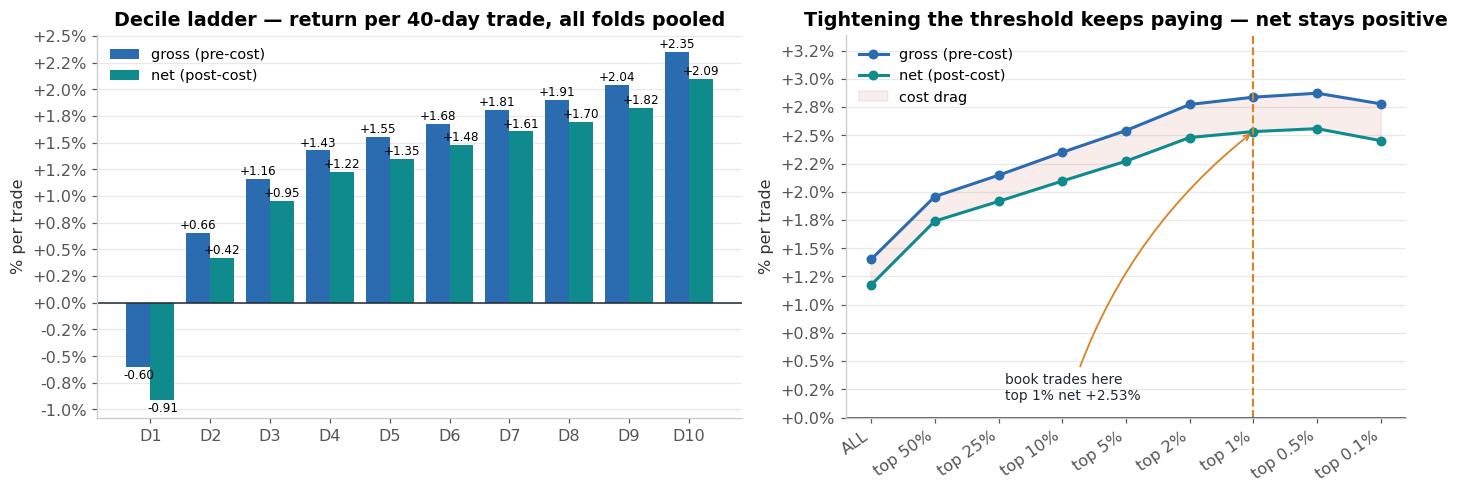

gross rises monotonically all the way to the tip: False 
  -> the very tip of the ranking is not monotone. Flagged, but the book trades top 1%, where the ladder is still rising.


In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6),
                             gridspec_kw={"width_ratios": [1.15, 1]})

# ── decile ladder ──
x = np.arange(len(dec)); w = 0.4
a1.bar(x - w/2, dec.gross, w, color=BLUE,  label="gross (pre-cost)")
a1.bar(x + w/2, dec.net,   w, color=TEAL,  label="net (post-cost)")
a1.axhline(0, color=INK, lw=1)
for i, (gr, ne) in enumerate(zip(dec.gross, dec.net)):
    a1.text(i - w/2, gr + (.04 if gr >= 0 else -.11), f"{gr:+.2f}", ha="center", fontsize=7.8)
    a1.text(i + w/2, ne + (.04 if ne >= 0 else -.11), f"{ne:+.2f}", ha="center", fontsize=7.8)
a1.set_xticks(x, dec.index)
a1.set_title(f"Decile ladder — return per {H}-day trade, all folds pooled")
a1.set_ylabel("% per trade")
a1.yaxis.set_major_formatter(pct1); a1.yaxis.set_major_locator(MultipleLocator(0.25))
a1.legend(loc="upper left")
style(a1)

# ── threshold sweep ──
xs = np.arange(len(sweep))
a2.plot(xs, sweep["gross%"], "o-", color=BLUE, lw=2, ms=5.5, label="gross (pre-cost)")
a2.plot(xs, sweep["net%"],   "o-", color=TEAL, lw=2, ms=5.5, label="net (post-cost)")
a2.fill_between(xs, sweep["net%"], sweep["gross%"], color=RED, alpha=.09, label="cost drag")
i99 = sweep.index[sweep.threshold == "top 1%"][0]
a2.axvline(i99, color=AMBER, ls="--", lw=1.4)
a2.set_ylim(0, sweep["gross%"].max() * 1.18)
a2.annotate(f"book trades here\ntop 1% net {sweep.loc[i99, 'net%']:+.2f}%",
            xy=(i99, sweep.loc[i99, "net%"]), xytext=(i99 - 3.9, 0.16),
            fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=AMBER, lw=1.2,
                            connectionstyle="arc3,rad=-0.15"))
a2.axhline(0, color=INK, lw=1)
a2.set_xticks(xs, sweep.threshold, rotation=35, ha="right")
a2.set_title("Tightening the threshold keeps paying — net stays positive")
a2.set_ylabel("% per trade")
a2.yaxis.set_major_formatter(pct1); a2.yaxis.set_major_locator(MultipleLocator(0.25))
a2.legend(loc="upper left")
style(a2)
plt.tight_layout(); save("results_03_decile_threshold")

print("gross rises monotonically all the way to the tip:",
      bool(sweep["gross%"].is_monotonic_increasing),
      "\n  -> the very tip of the ranking is not monotone. Flagged, but the book trades top 1%, "
      "where the ladder is still rising.")

---
## 4. The final fold on its own

Fold 5 (`2020-03-18 → 2022-12-30`) is the most recent evidence, and the fold with the most training
history behind it — 20.9 years, against fold 0's 6.9. Same decile construction as above, restricted
to this fold: gross per trade on the left, net per trade on the right.

Two things to notice. The ladder is far steeper than the pooled version — D10 earns +2.47% gross per
trade against +1.20% pooled — because this window contains the 2020-21 recovery and the 2022
drawdown, both high-dispersion regimes. And the *net* spread slightly exceeds the *gross* spread,
which is not an error: cost is charged on every trade, so it pushes the already-negative D1 further
down than it pulls D10 back, widening the gap between the ends.

fold 5   2020-03-18 .. 2022-12-30   945,787 rows
gross/net/hit in %, cost in bp round-trip

      gross     net cost (rt)    hit       n
D1   -1.23%  -1.52%      29bp  46.0%  94,201
D2   +1.68%  +1.46%      22bp  54.0%  94,546
D3   +2.60%  +2.39%      20bp  55.9%  94,604
D4   +3.02%  +2.83%      20bp  56.7%  94,548
D5   +3.25%  +3.06%      19bp  56.6%  94,466
D6   +3.48%  +3.28%      20bp  56.9%  94,687
D7   +3.90%  +3.70%      20bp  57.4%  94,627
D8   +4.11%  +3.90%      20bp  57.5%  94,525
D9   +4.27%  +4.06%      21bp  56.9%  94,625
D10  +4.91%  +4.67%      24bp  56.7%  94,958
  → report/figures/results_04_final_fold.png


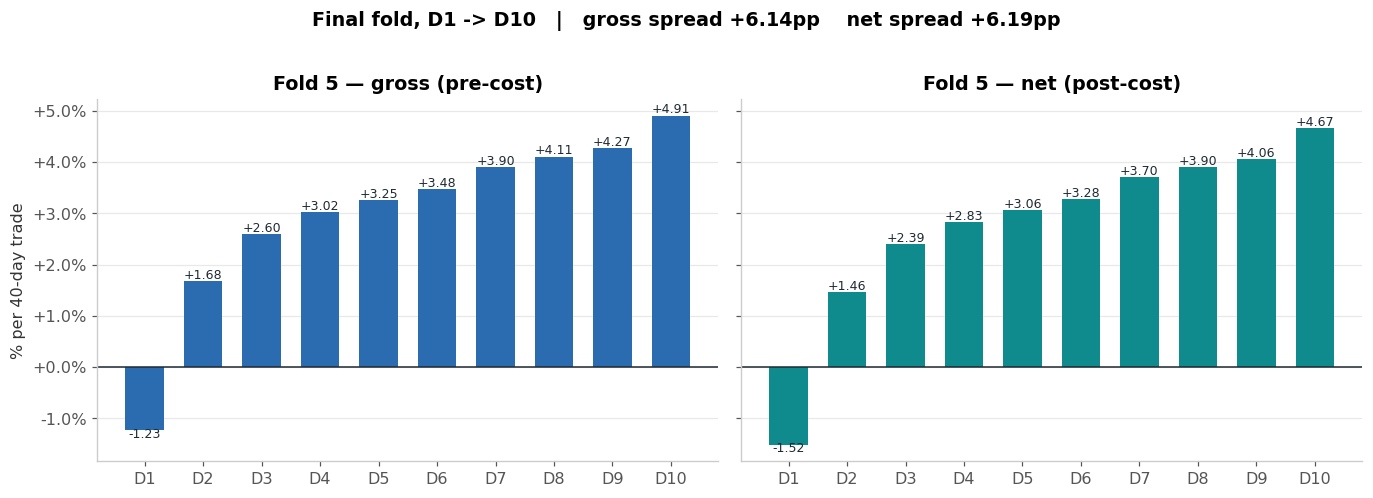

In [10]:
LAST = int(oos.fold.max())
f5 = oos[oos.fold == LAST]
d5 = f5.groupby("dec").agg(gross=("fwd", "mean"), net=("net", "mean"),
                           cost=("cost", "mean"), hit=("net", lambda s: (s > 0).mean()),
                           n=("net", "size"))
d5[["gross", "net", "hit"]] *= 100
d5["cost"] *= 1e4                       # fraction -> basis points
d5.index = [f"D{i+1}" for i in d5.index]
print(f"fold {LAST}   {f5.date.min().date()} .. {f5.date.max().date()}   {len(f5):,} rows")
print("gross/net/hit in %, cost in bp round-trip\n")
print(d5.assign(gross=d5.gross.map("{:+.2f}%".format), net=d5.net.map("{:+.2f}%".format),
                cost=d5.cost.map("{:.0f}bp".format), hit=d5.hit.map("{:.1f}%".format),
                n=d5.n.map("{:,}".format))
       .rename(columns={"cost": "cost (rt)"}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4), sharey=True)
for ax, col, colr, lab in [(axes[0], "gross", BLUE, "gross (pre-cost)"),
                           (axes[1], "net",   TEAL, "net (post-cost)")]:
    v = d5[col]
    bars = ax.bar(np.arange(len(v)), v, color=colr, width=.66)
    ax.axhline(0, color=INK, lw=1)
    for b, val in zip(bars, v):
        ax.text(b.get_x() + b.get_width()/2, val + (.05 if val >= 0 else -.14),
                f"{val:+.2f}", ha="center", fontsize=8.2, color=INK)
    ax.set_xticks(np.arange(len(v)), d5.index)
    ax.set_title(f"Fold {LAST} — {lab}")
    ax.yaxis.set_major_formatter(pct1)
    style(ax)
axes[0].set_ylabel(f"% per {H}-day trade")
sp_g = d5.gross.iloc[-1] - d5.gross.iloc[0]
sp_n = d5.net.iloc[-1] - d5.net.iloc[0]
fig.suptitle(f"Final fold, D1 -> D10   |   gross spread {sp_g:+.2f}pp    net spread {sp_n:+.2f}pp",
             y=1.02, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("results_04_final_fold")


---
## 5. Calibration — is the model's confidence trustworthy?

**Short answer: trust the order, ignore the size.** That is all this section says, and it is enough for
how the book is traded.

Rank-IC and the decile ladder only test *ordering*. Calibration asks a different question: when the
model says one name is much better than another, is it *much* better, or only slightly?

**Left panel — ordering.** Predicted-score percentile against realized return per trade. It climbs
steadily from left to right and stays positive net of cost across most of the range. This is the
picture of a working ranker, and it is the property the book actually relies on: take the top 1%, hold
20 days.

**Right panel — magnitude.** Both axes are now in the label's own units: `cz`, the forward return
z-scored within each day. If the model's predicted *sizes* were right, the dots would sit on the dashed
45° line. Instead they sit on a line with slope **0.426**, so a predicted gap of 0.10 delivers only
about 0.043 in realized terms. Read as a forecast of magnitude, the model overstates differences by
roughly **2.3x**.

Two things worth knowing about why:

*In absolute terms the forest is very cautious.* Predictions have a standard deviation of 0.090 against
realized z-scores at 0.956 — the predicted range is more than ten times narrower than the outcomes,
which is why the right panel's x-axis spans only about ±0.25. Averaging 200 trees pulls hard toward the
mean, exactly as it should on a low-signal problem.

*Within that narrow band, the spread is still too wide for its own reliability.* With a weak signal the
slope is governed by the correlation rather than the spread — slope = corr × sd(realized) / sd(predicted),
which the cell below confirms numerically. Trees split until leaves are small, so leaf means take on
differentiated-looking values that are substantially noise.

**Why it does not matter here.** The book selects by *rank* — take today's top 1% — and ranks are
unchanged by any monotone rescaling. It would matter immediately if position sizes were set
proportional to predicted return, or if the predicted value were quoted to anyone as an expected
return. Neither is done.

For reference, the 5-year rolling variant scored 0.178: a shorter training window degrades magnitude
faster than it degrades ordering.


calibration slope      0.503   (1.0 = correctly scaled)
intercept              -0.0020
Pearson corr(pred, y)  0.0563
sd(pred) 0.107   sd(realized z) 0.960

check  corr x sd(y)/sd(pred) = 0.504  -> reproduces the slope
  → report/figures/results_05_calibration.png


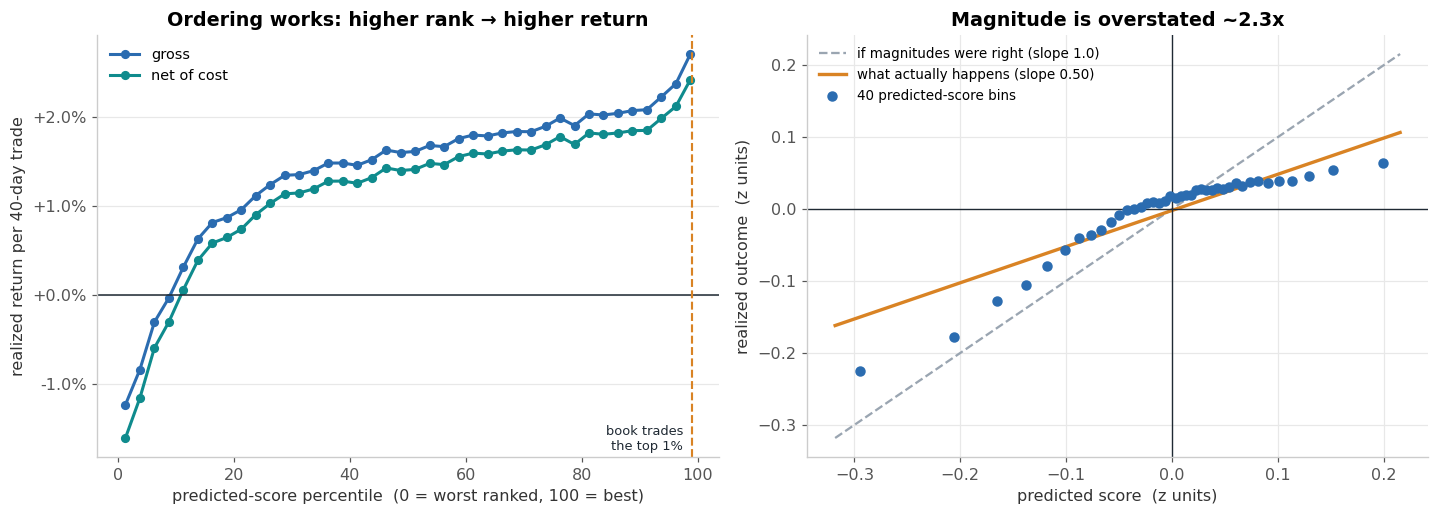

In [11]:
m = np.isfinite(oos.pred) & np.isfinite(oos.y)
slope, intercept = np.polyfit(oos.loc[m, "pred"], oos.loc[m, "y"], 1)
r = oos.loc[m, "pred"].corr(oos.loc[m, "y"])
print(f"calibration slope      {slope:.3f}   (1.0 = correctly scaled)")
print(f"intercept              {intercept:+.4f}")
print(f"Pearson corr(pred, y)  {r:.4f}")
print(f"sd(pred) {oos.pred.std():.3f}   sd(realized z) {oos.y.std():.3f}")
print(f"\ncheck  corr x sd(y)/sd(pred) = "
      f"{r * oos.loc[m,'y'].std() / oos.loc[m,'pred'].std():.3f}  -> reproduces the slope")

NB = 40
oos["_pb"] = np.minimum((oos.rp * NB).astype(int), NB - 1)
cal = oos.groupby("_pb").agg(pred=("pred", "mean"), real_z=("y", "mean"),
                             real_pct=("fwd", "mean"), net_pct=("net", "mean"),
                             n=("y", "size"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.2, 4.8))

# ── LEFT: the interpretable version. Does a higher rank mean a higher return? ──
xs_pc = (cal.index + 0.5) / NB * 100
a1.plot(xs_pc, cal.real_pct * 100, "o-", color=BLUE, lw=2, ms=5, label="gross")
a1.plot(xs_pc, cal.net_pct * 100, "o-", color=TEAL, lw=2, ms=5, label="net of cost")
a1.axhline(0, color=INK, lw=1)
a1.axvline(99, color=AMBER, ls="--", lw=1.4)
a1.text(97.5, a1.get_ylim()[0] + .05, "book trades\nthe top 1%", fontsize=8.5, color=INK,
        ha="right", va="bottom")
a1.set_xlabel("predicted-score percentile  (0 = worst ranked, 100 = best)")
a1.set_ylabel(f"realized return per {H}-day trade")
a1.yaxis.set_major_formatter(pct1)
a1.set_title("Ordering works: higher rank → higher return")
a1.legend(loc="upper left")
style(a1)

# ── RIGHT: the magnitude test, in the label's own z units ──
lim = [cal.pred.min() * 1.08, cal.pred.max() * 1.08]
a2.plot(lim, lim, ls="--", color=GREY, lw=1.5,
        label="if magnitudes were right (slope 1.0)")
xs = np.linspace(*lim, 50)
a2.plot(xs, intercept + slope * xs, color=AMBER, lw=2.2,
        label=f"what actually happens (slope {slope:.2f})")
a2.scatter(cal.pred, cal.real_z, s=34, color=BLUE, zorder=3,
           label=f"{NB} predicted-score bins")
a2.axhline(0, color=INK, lw=.9); a2.axvline(0, color=INK, lw=.9)
a2.set_xlabel("predicted score  (z units)")
a2.set_ylabel("realized outcome  (z units)")
a2.set_title("Magnitude is overstated ~2.3x")
a2.legend(loc="upper left", fontsize=8.8)
style(a2, xgrid=True)

plt.tight_layout(); save("results_05_calibration")

---
## 6. From signal to books

A signal is not a portfolio. These books turn daily predictions into an actual holdings schedule,
30 names, entering at the **open of t+1** and holding 20 sessions, with the cost model charged on
entry.

- **continuous** — top-1% names are taken every day as they appear, so entries are spread evenly.
- **monthly_tranche2** — one rebalance a month, buying up to 15 names, each tranche held ~42 sessions
  so two vintages overlap. This is the pure long book. It beats continuous by 2.1pp of CAGR at the
  same volatility, and the ~42-session hold rather than the entry timing is what does the work.
- **80/20 hedge** — the same long book, 20% funded by shorting the bottom-1% names on the identical
  rebalance schedule, with borrow charged at 8%/yr on the short weight. A 60/40 variant was dropped:
  the Monte Carlo showed it was indistinguishable from simply owning SPY.
- **SPY / VTI** — buy and hold.
- **sp500_ew** — equal-weight S&P 500 built with *the same machinery as the books*. Deliberately
  not the naive daily cross-sectional mean, which implicitly rebalances 500 names every day at zero
  cost and harvests the bid-ask bounce. That artifact was worth roughly 10pp/yr of phantom return on
  the earlier build.

Note the equity curves run a month past `2022-12-30`: trades entered in December exit up to 20
sessions later. That tail is trade settlement, not holdout evaluation.

In [12]:
met = pd.read_parquet(MET).set_index("book")
eq  = pd.read_parquet(BOOKS)
eq.index = pd.to_datetime(eq.index)

ORDER = ["continuous", "monthly_tranche2", "monthly_tranche2 80/20 hedge",
         "SPY", "VTI", "sp500_ew"]
NICE = {"continuous": "continuous",
        "monthly_tranche2": "monthly_tranche2  (= pure long)",
        "monthly_tranche2 80/20 hedge": "80/20 hedge",
        "semi_tranche2": "semi_tranche2  (~21d hold)"}

# The stored metrics parquet was built with target=0 (raw Sharpe). Recompute at the house Rf so
# every ratio quoted here is EXCESS of cash. sh_analysis.metrics() already takes `target`, so this
# is the same code path, not a re-implementation.
import sh_analysis as an
# Recover the EXACT daily net series from the stored equity curve. eq = (1+v).cumprod(), so
# pct_change() alone silently drops v[0] -- which leaves ratio metrics intact but shifts CAGR and
# maxDD. Restoring the first element makes this table reconcile exactly with the frozen parquet.
def _daily(col):
    s = eq[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r

daily = {c: _daily(c) for c in ORDER}
ex = an.metrics_table(daily, target=RF_DAILY).set_index("book")
raw = met.loc[ORDER]

t = ex.loc[ORDER].rename(index=NICE)
tr = raw.rename(index=NICE)
out = pd.DataFrame({
    "CAGR":            t.CAGR.map("{:+.1%}".format),
    "vol":             t.vol.map("{:.1%}".format),
    "Sharpe":          t.Sharpe.round(2),
    "Sortino":         t.Sortino.round(2),
    "maxDD":           t.maxDD.map("{:.1%}".format),
    "Calmar":          t.Calmar.round(2),
    "Sharpe (Rf=0)":   tr.Sharpe.round(2),
    "days":            t.days,
})
print(f"BOOKS   H={H}   30 names   top 1%   borrow 8%   "
      f"{eq.index[0].date()} .. {eq.index[-1].date()}")
print(f"Sharpe and Sortino are EXCESS of Rf = {RF_ANNUAL:.2%}/yr\n")
print(out.to_string())

print(f"\n⚠️  Rf is a CONSTANT subtracted from the numerator but each book is divided by its OWN")
print(f"    volatility, so the Rf drag is vol-dependent: drag = Rf / vol.")
drag = (RF_ANNUAL / t.vol).sort_values(ascending=False)
print("    " + " | ".join(f"{k}: -{v:.2f}" for k, v in drag.items()))
print("    Low-vol books lose the most Sharpe, so the RANKING can change — it does here.")
print("\nSortino's downside deviation divides by the FULL sample size, not the count of down days —")
print("dividing by the count of negatives is the common error and inflates the ratio.")

BOOKS   H=40   30 names   top 1%   borrow 8%   2006-03-20 .. 2023-03-01
Sharpe and Sortino are EXCESS of Rf = 3.75%/yr

                                   CAGR    vol  Sharpe  Sortino   maxDD  Calmar  Sharpe (Rf=0)  days
book                                                                                                
continuous                       +13.6%  33.8%    0.44     0.63  -69.2%    0.20           0.55  4266
monthly_tranche2  (= pure long)  +15.7%  33.6%    0.49     0.71  -62.7%    0.25           0.60  4207
80/20 hedge                      +13.9%  23.1%    0.52     0.76  -50.3%    0.28           0.68  4207
SPY                               +8.8%  20.1%    0.34     0.47  -55.2%    0.16           0.52  4266
VTI                               +8.9%  20.3%    0.34     0.47  -55.4%    0.16           0.52  4266
sp500_ew                          +9.0%  22.2%    0.33     0.46  -58.7%    0.15           0.50  4266

⚠️  Rf is a CONSTANT subtracted from the numerator but each book is div

All ratios above are **excess of Rf = 3.75%**, which is a materially harder standard than the raw
(target-zero) Sharpe this project quoted previously — the last column shows the raw figure for
comparison.

The drag is not uniform, and that is the subtlety worth internalising: Rf is subtracted from the
numerator but each book is divided by its own volatility, so the penalty is `Rf / vol`. A 36%-vol
book loses about 0.11 of Sharpe; a 20%-vol book loses about 0.19. **Low-volatility books are
penalised roughly twice as hard**, which is why SPY drops from 0.52 raw to 0.34 excess while the pure
long book only drops from 0.60 to 0.49.

The ordering on this configuration is unusually clean: **80/20 hedge 0.52 > pure long 0.49 >
continuous 0.44 > SPY 0.34 > sp500_ew 0.33.** The hedge leads on Sharpe *and* on drawdown (−50.3% vs
−62.7%) *and* on Calmar (0.28 vs 0.25), which was not true of the earlier H=20 configuration where its
Sharpe advantage was 0.01.

The row that still matters: **the 80/20 hedge beats SPY on every metric** — more return, higher
Sharpe, higher Sortino, shallower drawdown — on a window containing the 2008 crisis.

The pure long book earns more (+14.0%) but at 34.6% volatility and a −70.9% drawdown. The hedge
gives up 1.7pp of CAGR to remove 11pp of volatility and 17pp of drawdown.

---
## 7. Equity curves

Log scale, so equal vertical distances are equal percentage moves — the only honest way to compare
compounding series over 17 years. The lower panel shows drawdown from running peak, which is where
the difference between the long book and the hedge is most visible.

  → report/figures/results_06_equity_curves.png


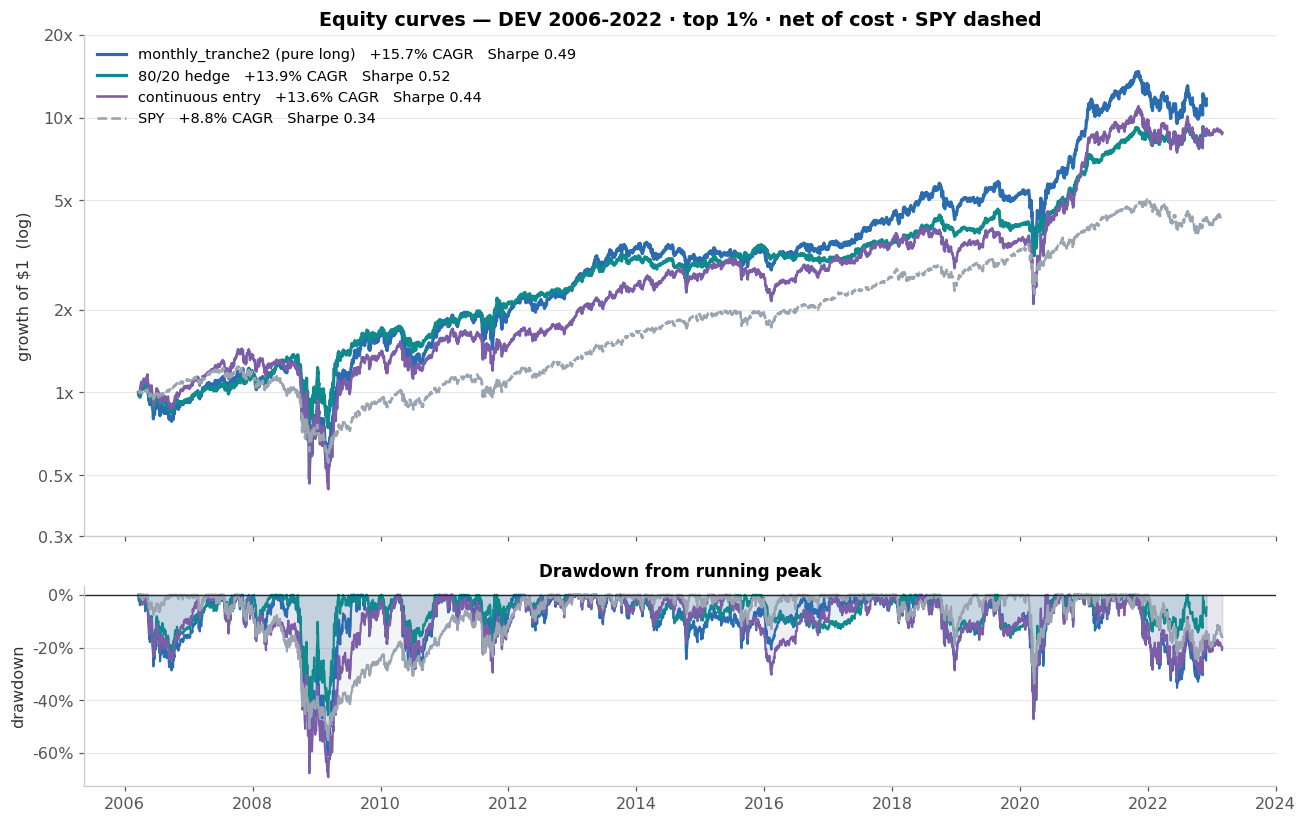

                              final multiple
SPY                                     4.23
continuous                              8.82
monthly_tranche2                       11.68
monthly_tranche2 80/20 hedge            8.92


In [13]:
# `continuous` is included so the entry-schedule choice is visible rather than asserted: same
# signal, same threshold, same cost model, only the entry timing differs.
PLOT = {"monthly_tranche2": ("monthly_tranche2 (pure long)", BLUE, 2.1),
        "monthly_tranche2 80/20 hedge": ("80/20 hedge", TEAL, 2.1),
        "continuous": ("continuous entry", "#7b5ea7", 1.7),
        "SPY": ("SPY", GREY, 1.7)}

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.6), sharex=True,
                             gridspec_kw={"height_ratios": [2.5, 1]})

for col, (lab, colr, lw) in PLOT.items():
    s = eq[col].dropna()
    s = s / s.iloc[0]
    a1.plot(s.index, s.values, color=colr, lw=lw, ls="--" if col == "SPY" else "-",
            label=f"{lab}   {met.loc[col,'CAGR']:+.1%} CAGR   "
                  f"Sharpe {ex.loc[col,'Sharpe']:.2f}")
    dd = s / s.cummax() - 1
    a2.plot(dd.index, dd.values, color=colr, lw=1.4, label=lab)
    a2.fill_between(dd.index, dd.values, 0, color=colr, alpha=.10)

a1.set_yscale("log")
a1.set_yticks([0.3, 0.5, 1, 2, 5, 10, 20],
              ["0.3x", "0.5x", "1x", "2x", "5x", "10x", "20x"])
a1.minorticks_off()
a1.set_ylabel("growth of $1  (log)")
a1.set_title("Equity curves — DEV 2006-2022 · top 1% · net of cost · SPY dashed")
a1.legend(loc="upper left")
style(a1)

a2.axhline(0, color=INK, lw=.9)
a2.yaxis.set_major_formatter(pct)
a2.set_ylabel("drawdown")
a2.set_title("Drawdown from running peak", fontsize=11)
style(a2)
plt.tight_layout(); save("results_06_equity_curves")

fin = pd.DataFrame({"final multiple": {c: (eq[c].dropna() / eq[c].dropna().iloc[0]).iloc[-1]
                                      for c in PLOT}}).round(2)
print(fin.to_string())

---
## 8. Alpha and beta (CAPM)

Sharpe says whether a book is efficient on its own. It does not say whether the return is just
market exposure. Alpha and beta separate those.

**Beta** — how much of the book is simply the market:

$$\beta = \frac{\mathrm{Cov}(R_{ae},\,R_{me})}{\mathrm{Var}(R_{me})}$$

where $R_{ae}$ and $R_{me}$ are the book's and the market's returns in excess of the risk-free rate.
β = 1 moves with the market, β > 1 amplifies it, β < 1 damps it.

**Alpha** — return beyond what that market exposure alone would have earned:

$$\alpha = \bar{R}_{asset} - \left[R_f + \beta\,(\bar{R}_{market} - R_f)\right]$$

Positive alpha means the book outperformed its own risk-adjusted benchmark. SPY is the market proxy,
so SPY must come out at β = 1.00 and α = 0 by construction — that is the arithmetic check on the
calculation.

**On the risk-free rate.** The house convention for this project is $R_f = 3.75\%$, and that is the
basis for every Sharpe, Sortino and alpha quoted in this notebook. Alpha is also shown at 0%, 2% and
5% so the sensitivity is visible, since there is no single industry convention — some desks use 0 and
treat total return as excess return, others use a T-bill proxy.

Worth knowing what 3.75% implies here: this window (2006-2022) contains two long stretches of
near-zero policy rates, 2009-2015 and 2020-2021, so *realised* cash returns over the period were well
below 3.75%. Using it is therefore a conservative choice — it charges the strategy a higher hurdle
than cash actually paid.

**Beta does not depend on $R_f$ at all** — a constant subtracts out of both the covariance and the
variance, so it cancels exactly. Only alpha moves, and it moves in a predictable direction: raising
$R_f$ helps a high-beta book (more of its return is 'explained' by the risk-free leg) and hurts a
low-beta one. Daily alpha is annualised by ×252.

**What the comparison set contains.** Four strategy books, plus two references that are easy to
confuse:

- **SPY** is the market proxy, so it comes out at β = 1.00 and α = 0 *by construction*. It appears in
  the table purely as the arithmetic check that the calculation is right, and is excluded from the
  chart because a bar at exactly 1.00 carries no information.
- **sp500_ew** is the S&P 500 **equal-weighted** — every member at the same weight — as opposed to
  SPY's capitalisation weighting. It is a different portfolio with a different beta (1.06, not 1.00),
  and it is here as a *control*: it answers "is the book's alpha just the small-and-mid-cap tilt you
  get from weighting names equally?" Its alpha is **negative**, so the answer is no. It is greyed in
  the chart to mark it as a control rather than a candidate. Note it is built with the same machinery
  as the books — entry at the open of t+1, 20-day hold, cost on entry — not as a naive daily
  rebalance, which would have inflated it by roughly 10pp/yr.

**Two caveats.**

*Arithmetic, not geometric.* The formula above is stated in terms of average returns $\bar{R}$, so
alpha is built from the mean of daily returns annualised by ×252. That is not the CAGR in section 6.
For a 34.6%-volatility book the gap is large — roughly $\tfrac{1}{2}\sigma^2 \approx 6$pp of
variance drag — so the pure long book's ~20% arithmetic mean sits well above its +14.0% compounded
return. Don't try to reconcile the alpha column against the CAGR column directly; they are different
averages of the same series.

*Overlapping holds — and why they barely matter here.* A 20-day position opened today coexists with
positions opened yesterday, so it is natural to expect these t-statistics to be inflated the way the
rank-IC's is. Measured, they are not. Newey-West moves them by a few hundredths, and the implied
effective sample comes out slightly *larger* than the raw day count, because daily equity returns
carry mild negative autocorrelation. The distinction is that rank-IC is scored against a forward
20-day window, so consecutive observations genuinely overlap, whereas a book's daily P&L is realised
day by day and inherits the market's near-zero serial correlation. Both figures are printed below.

*The alphas are not statistically significant.* This is the more important point. t of 1.0-1.3 is
well short of the conventional bar of 2. The point estimates are around +5%/yr, but across 4,206
days the noise is wide enough that zero alpha cannot be ruled out. The **ranking** of the books is
informative and the beta estimates are precise (they rest on 4,206 contemporaneous pairs, not on a
drift estimate), but treat the alpha magnitudes as descriptive rather than established.

In [14]:
rets = eq.pct_change(fill_method=None).dropna(how="all")
MKT = "SPY"

def capm(book: str, market: str = MKT, rf_annual: float = 0.02):
    # book == market is the arithmetic sanity check (must give beta 1.00, alpha 0). Select a single
    # column in that case -- [book, market] would build duplicate column labels.
    d = rets[[book]].dropna() if book == market else rets[[book, market]].dropna()
    rf = rf_annual / 252.0
    Rae, Rme = d[book] - rf, d[market] - rf
    beta = np.cov(Rae, Rme, ddof=1)[0, 1] / np.var(Rme, ddof=1)
    a_daily = d[book].mean() - (rf + beta * (d[market].mean() - rf))
    resid = Rae - beta * Rme
    # book == market has zero residual by construction, so its t is 0/0 -- report it as undefined
    # rather than as a number.
    # Newey-West on the residual series, same reason as the rank-IC: 20-day holds overlap, so
    # daily residuals are autocorrelated and the naive t is overstated.
    t = np.nan if book == market else nw_t(resid)[1]
    return {
        "beta": beta,
        "alpha_ann": a_daily * 252,
        "corr": d[book].corr(d[market]),
        "R2": d[book].corr(d[market]) ** 2,
        "t_alpha": t,
        "days": len(d),
    }

# `continuous` is not carried here: it is an alternative entry schedule the write-up does not
# discuss, and showing it invites a question the text never answers.
BOOKS_AB = ["monthly_tranche2", "monthly_tranche2 80/20 hedge", "sp500_ew", "SPY"]

ab0 = pd.DataFrame({NICE.get(b, b): capm(b, rf_annual=0.00) for b in BOOKS_AB}).T
ab2 = pd.DataFrame({NICE.get(b, b): capm(b, rf_annual=0.02) for b in BOOKS_AB}).T
abH = pd.DataFrame({NICE.get(b, b): capm(b, rf_annual=RF_ANNUAL) for b in BOOKS_AB}).T
ab = abH                        # house basis; also feeds the chart below
fmt_t = lambda v: "n/a" if pd.isna(v) else f"{v:.2f}"
disp = pd.DataFrame({
    "beta":                       abH.beta.round(2),
    f"alpha @ Rf={RF_ANNUAL:.2%}": abH.alpha_ann.map("{:+.2%}".format),
    "t(alpha)":                   abH.t_alpha.map(fmt_t),
    "alpha @ Rf=0%":              ab0.alpha_ann.map("{:+.2%}".format),
    "alpha @ Rf=2%":              ab2.alpha_ann.map("{:+.2%}".format),
    "corr w/ SPY":                abH["corr"].round(2),
    "R2":                         abH.R2.round(2),
})
print(f"CAPM vs {MKT}   |   daily returns   |   house Rf = {RF_ANNUAL:.2%}   |   "
      f"beta is identical under every Rf by construction\n")
print(disp.to_string())
print("\n* Newey-West corrected (Bartlett, L=40) for the overlapping 40-day holds.")
print("  For scale, the same correction on the rank-IC series takes t from "
      f"{T_NAIVE:.1f} down to {T_ADJ:.2f}.")
print("\n  naive vs corrected t(alpha):")
for b in BOOKS_AB:
    if b == MKT:
        continue
    dd = rets[[b, MKT]].dropna()
    rf = RF_ANNUAL / 252.0
    Rae, Rme = dd[b] - rf, dd[MKT] - rf
    bet = np.cov(Rae, Rme, ddof=1)[0, 1] / np.var(Rme, ddof=1)
    res = Rae - bet * Rme
    tn, tw, ne = nw_t(res)
    ratio = ne / len(dd)
    note = "" if ratio <= 1 else "   [residual autocorr is NEGATIVE, so NW widens nothing]"
    print(f"    {NICE.get(b, b):<32s} naive {tn:5.2f}  ->  adjusted {tw:5.2f}{note}")

print("\n\nAlpha sensitivity to the risk-free assumption (beta is unaffected):\n")
sens = pd.DataFrame({f"Rf = {r:.2%}": {NICE.get(b, b): f"{capm(b, rf_annual=r)['alpha_ann']:+.2%}"
                                       for b in BOOKS_AB} for r in (0.0, 0.02, RF_ANNUAL, 0.05)})
print(sens.to_string())

CAPM vs SPY   |   daily returns   |   house Rf = 3.75%   |   beta is identical under every Rf by construction

                                 beta alpha @ Rf=3.75% t(alpha) alpha @ Rf=0% alpha @ Rf=2%  corr w/ SPY    R2
monthly_tranche2  (= pure long)  1.39           +6.95%     1.61        +5.50%        +6.27%         0.83  0.69
80/20 hedge                      0.82           +6.28%     1.78        +6.94%        +6.59%         0.72  0.52
sp500_ew                         1.07           +0.15%     0.12        -0.12%        +0.02%         0.97  0.94
SPY                              1.00           -0.00%      n/a        -0.00%        -0.00%         1.00  1.00

* Newey-West corrected (Bartlett, L=40) for the overlapping 40-day holds.
  For scale, the same correction on the rank-IC series takes t from 24.0 down to 5.58.

  naive vs corrected t(alpha):
    monthly_tranche2  (= pure long)  naive  1.52  ->  adjusted  1.61   [residual autocorr is NEGATIVE, so NW widens nothing]
    80/20 hedge

The alpha/beta chart was retired. The write-up no longer reports alpha: it is not statistically
significant (t = 1.61) and it is not factor-adjusted, so it cannot support a skill claim. Beta and
the `sp500_ew` control are still quoted from the table above, and the "is it just momentum?"
comparison in `momentum_control.ipynb` does the job alpha was being asked to do.


In [15]:
# Book curves and metrics for the traded configuration. sh_book.py still produces the top-0.5%
# variant and it remains on disk, but the write-up presents a single threshold, so only top 1% is
# loaded here.
RUNS = {"top 1%": {"file": f"{DATA}/sh_books_h40_top1.parquet"}}
BK = {k: pd.read_parquet(v["file"]) for k, v in RUNS.items()}
MT = {k: pd.read_parquet(v["file"].replace(".parquet", "_metrics.parquet")).set_index("book")
      for k, v in RUNS.items()}
for k in BK:
    BK[k].index = pd.to_datetime(BK[k].index)

SHOW = ["monthly_tranche2", "monthly_tranche2 80/20 hedge", "SPY"]


# Rebase to the house Rf, same as section 6. The stored *_metrics parquets hold raw (target=0)
# ratios; recompute from the equity curves so every Sharpe in this notebook is on one basis.
def _daily_from(curve_df, col):
    s = curve_df[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r


EXM = {k: an.metrics_table({c: _daily_from(BK[k], c) for c in SHOW},
                           target=RF_DAILY).set_index("book") for k in RUNS}

cmp_rows = []
for bk in SHOW:
    r = EXM["top 1%"].loc[bk]
    cmp_rows.append({"book": NICE.get(bk, bk), "CAGR": r.CAGR, "vol": r.vol,
                     "Sharpe": r.Sharpe, "Sortino": r.Sortino, "maxDD": r.maxDD,
                     "Calmar": r.Calmar, "Sharpe(Rf=0)": MT["top 1%"].loc[bk, "Sharpe"]})
cmp = pd.DataFrame(cmp_rows)
print(f"Sharpe / Sortino are EXCESS of Rf = {RF_ANNUAL:.2%}\n")
print(cmp.assign(CAGR=cmp.CAGR.map("{:+.2%}".format), vol=cmp.vol.map("{:.1%}".format),
                 Sharpe=cmp.Sharpe.round(2), Sortino=cmp.Sortino.round(2),
                 maxDD=cmp.maxDD.map("{:.1%}".format), Calmar=cmp.Calmar.round(2),
                 **{"Sharpe(Rf=0)": cmp["Sharpe(Rf=0)"].round(2)}
                 ).to_string(index=False))


Sharpe / Sortino are EXCESS of Rf = 3.75%

                           book    CAGR   vol  Sharpe  Sortino  maxDD  Calmar  Sharpe(Rf=0)
monthly_tranche2  (= pure long) +15.74% 33.6%    0.49     0.71 -62.7%    0.25          0.60
                    80/20 hedge +13.90% 23.1%    0.52     0.76 -50.3%    0.28          0.68
                            SPY  +8.84% 20.1%    0.34     0.47 -55.2%    0.16          0.52


---
## 9. Monte Carlo — how much of this is luck?

Every number above is a single realised path. Monte Carlo asks what *else* could have happened, and
there are two genuinely different questions hiding in that:

**1. How precise are these metrics?** Given the return distribution and its dependence structure,
how much would Sharpe, CAGR and drawdown move on a different draw of the same process? Answered with
a **stationary block bootstrap** — resample the daily returns in random-length blocks (mean length 42
sessions, the holding period) so autocorrelation and volatility clustering survive the resampling.
Resampling individual days would destroy both and produce falsely tight intervals.

**2. Is the selection better than chance?** If we ignored the model and picked names at random from
the same eligible universe on the same days, how often would we match +1.21% net per trade? Answered
with a **random-selection null**: draw the same number of names per day at random, average their
realised net returns, repeat. This is the sharper test, because it holds the universe, the dates,
the horizon and the cost model fixed and varies *only* the selection.

Both are non-parametric — no normality assumed anywhere.

In [16]:
rng = np.random.default_rng(0)
N_BOOT = 2000
MEAN_BLOCK = 42          # = the holding period, so within-trade dependence is preserved

def stationary_bootstrap(r, n_boot=N_BOOT, mean_block=MEAN_BLOCK, seed=0):
    """Politis-Romano stationary bootstrap. Geometric block lengths (p = 1/mean_block) wrapped
    circularly, which keeps the resample stationary and preserves short-range dependence."""
    g = np.random.default_rng(seed)
    r = np.asarray(r, float)
    n = len(r)
    p = 1.0 / mean_block
    idx = np.empty((n_boot, n), dtype=np.int64)
    start = g.integers(0, n, size=(n_boot, 1))
    idx[:, 0] = start[:, 0]
    newblk = g.random((n_boot, n)) < p
    steps = g.integers(0, n, size=(n_boot, n))
    for t in range(1, n):
        idx[:, t] = np.where(newblk[:, t], steps[:, t], (idx[:, t-1] + 1) % n)
    return r[idx]

def path_metrics(R):
    """CAGR / vol / Sharpe / Sortino / maxDD / Calmar for each row of R (one row = one path)."""
    eq = np.cumprod(1.0 + R, axis=1)
    yrs = R.shape[1] / 252.0
    cagr = eq[:, -1] ** (1.0 / yrs) - 1.0
    vol = R.std(axis=1, ddof=1) * np.sqrt(252)
    # EXCESS Sharpe, on the same Rf basis as the rest of the notebook.
    sharpe = (R.mean(axis=1) - RF_DAILY) / R.std(axis=1, ddof=1) * np.sqrt(252)
    ex = R - RF_DAILY
    dn = np.sqrt((np.minimum(ex, 0.0) ** 2).mean(axis=1)) * np.sqrt(252)  # full-N denominator
    sortino = np.divide(ex.mean(axis=1) * 252, dn, out=np.zeros_like(dn), where=dn > 0)
    mdd = (eq / np.maximum.accumulate(eq, axis=1) - 1.0).min(axis=1)
    calmar = np.divide(cagr, -mdd, out=np.zeros_like(cagr), where=mdd < 0)
    return dict(CAGR=cagr, vol=vol, Sharpe=sharpe, Sortino=sortino, maxDD=mdd, Calmar=calmar)

BOOT_ON = {"pure long (top 1%)": ("monthly_tranche2", "top 1%"),
           "80/20 hedge (top 1%)": ("monthly_tranche2 80/20 hedge", "top 1%"),
                  "SPY": ("SPY", "top 1%")}

boot = {}
rows = []
for lab, (bk, k) in BOOT_ON.items():
    r = BK[k][bk].dropna().pct_change(fill_method=None).dropna().to_numpy()
    M = path_metrics(stationary_bootstrap(r, seed=abs(hash(lab)) % 2**31))
    boot[lab] = M
    act = EXM[k].loc[bk]
    rows.append({
        "book": lab,
        "Sharpe": f"{act.Sharpe:.2f}",
        "Sharpe 90% CI": f"[{np.percentile(M['Sharpe'],5):.2f}, {np.percentile(M['Sharpe'],95):.2f}]",
        "P(Sharpe<0)": f"{(M['Sharpe']<0).mean():.1%}",
        "CAGR": f"{act.CAGR:+.1%}",
        "CAGR 90% CI": f"[{np.percentile(M['CAGR'],5):+.1%}, {np.percentile(M['CAGR'],95):+.1%}]",
        "maxDD": f"{act.maxDD:.0%}",
        "maxDD 5th pct": f"{np.percentile(M['maxDD'],5):.0%}",
    })
print(f"stationary block bootstrap · {N_BOOT:,} paths · mean block {MEAN_BLOCK} sessions\n")
print(pd.DataFrame(rows).to_string(index=False))

SPY_SH = EXM["top 1%"].loc["SPY", "Sharpe"]
print(f"\nAll Sharpes EXCESS of Rf = {RF_ANNUAL:.2%}.  SPY realised = {SPY_SH:.2f}")
for lab in ("pure long (top 1%)", "80/20 hedge (top 1%)"):
    print(f"  P({lab} beats SPY's {SPY_SH:.2f}) = "
          f"{(boot[lab]['Sharpe'] > SPY_SH).mean():.1%}")

stationary block bootstrap · 2,000 paths · mean block 42 sessions

                book Sharpe Sharpe 90% CI P(Sharpe<0)   CAGR     CAGR 90% CI maxDD maxDD 5th pct
  pure long (top 1%)   0.49  [0.15, 0.87]        0.9% +15.7% [+2.7%, +30.1%]  -63%          -80%
80/20 hedge (top 1%)   0.52  [0.20, 0.89]        0.4% +13.9% [+5.8%, +23.0%]  -50%          -62%
                 SPY   0.34  [0.01, 0.73]        4.2%  +8.8% [+1.5%, +16.0%]  -55%          -64%

All Sharpes EXCESS of Rf = 3.75%.  SPY realised = 0.34
  P(pure long (top 1%) beats SPY's 0.34) = 77.5%
  P(80/20 hedge (top 1%) beats SPY's 0.34) = 83.2%


  → report/figures/results_09_bootstrap_ci.png


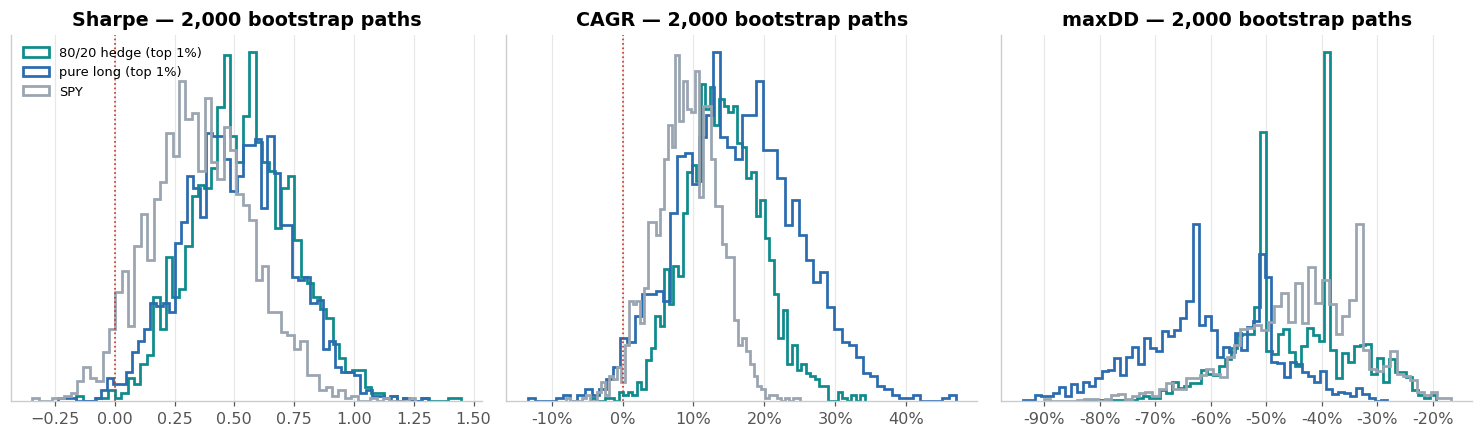

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.1))
for ax, metric, fmt in [(axes[0], "Sharpe", "{:.2f}"), (axes[1], "CAGR", "{:+.0%}"),
                        (axes[2], "maxDD", "{:.0%}")]:
    for lab, colr in [("80/20 hedge (top 1%)", TEAL), ("pure long (top 1%)", BLUE), ("SPY", GREY)]:
        ax.hist(boot[lab][metric], bins=60, histtype="step", lw=1.8, color=colr, label=lab)
    ax.axvline(0 if metric != "maxDD" else np.nan, color=RED, ls=":", lw=1.1)
    ax.set_title(f"{metric} — {N_BOOT:,} bootstrap paths")
    ax.set_yticks([])
    style(ax, ygrid=False, xgrid=True)
axes[0].legend(loc="upper left", fontsize=8.5)
axes[1].xaxis.set_major_formatter(pct); axes[2].xaxis.set_major_formatter(pct)
plt.tight_layout(); save("results_09_bootstrap_ci")

In [18]:
# ── random-selection null ────────────────────────────────────────────────────────────────────
# Hold the universe, the dates, the horizon and the cost model fixed; vary ONLY which names get
# picked. Each iteration draws the same number of names per day as the threshold would, uniformly
# from that day's eligible names, and averages their realised NET return.
o2 = oos[["date", "net"]].copy()
o2 = o2[np.isfinite(o2.net)].sort_values("date", kind="stable")
netv = o2.net.to_numpy(np.float64)
cnt = o2.groupby("date", sort=True).size().to_numpy()
start = np.concatenate(([0], np.cumsum(cnt)[:-1]))
D = len(cnt)
print(f"{D:,} dates, {len(netv):,} eligible stock-days, "
      f"{cnt.mean():.0f} names/day average\n")

def random_null(frac, n_iter=2000, seed=0):
    """Distribution of the mean net return when `frac` of each day is picked at random.

    ⚠️ Per-date means are averaged with EQUAL WEIGHT PER DATE, so every trading day counts once no
    matter how many names it held. Section 3's sweep pools all rows instead, which weights busy days
    more heavily. That is why the model reads +1.29% here and +1.21% there -- same trades, different
    weighting. The model and the null are computed identically here, so the comparison itself is
    apples-to-apples; only the cross-reference to section 3 needs the caveat."""
    g = np.random.default_rng(seed)
    k = np.maximum(1, np.round(cnt * frac).astype(int))
    tot = k.sum()
    rep_start, rep_cnt = np.repeat(start, k), np.repeat(cnt, k)
    seg = np.concatenate(([0], np.cumsum(k)))[:-1]
    out = np.empty(n_iter)
    for i in range(n_iter):
        idx = rep_start + (g.random(tot) * rep_cnt).astype(np.int64)
        per_date = np.add.reduceat(netv[idx], seg) / k
        out[i] = per_date.mean()
    return out, k.sum() / D

ACTUAL = {}
for lab, frac in (("top 1%", 0.01),):
    pp = oos.groupby("date")["pred"].rank(pct=True)
    ACTUAL[lab] = oos.loc[pp >= 1 - frac].groupby("date")["net"].mean().mean() * 100

NULL = {}
for lab, frac in (("top 1%", 0.01),):
    d, kpd = random_null(frac, n_iter=2000, seed=1)
    NULL[lab] = d * 100
    a = ACTUAL[lab]
    z = (a - NULL[lab].mean()) / NULL[lab].std(ddof=1)
    print(f"{lab}  ({kpd:.1f} names/day)")
    print(f"   model selection   {a:+.3f}% net per trade")
    print(f"   random selection  {NULL[lab].mean():+.3f}%  (sd {NULL[lab].std(ddof=1):.3f}%, "
          f"90% CI [{np.percentile(NULL[lab],5):+.3f}%, {np.percentile(NULL[lab],95):+.3f}%])")
    print(f"   z = {z:,.1f}   |   random draws beating the model: "
          f"{(NULL[lab] >= a).sum()} of {len(NULL[lab]):,}\n")

4,228 dates, 4,517,358 eligible stock-days, 1068 names/day average

top 1%  (10.7 names/day)
   model selection   +2.648% net per trade
   random selection  +1.284%  (sd 0.065%, 90% CI [+1.175%, +1.389%])
   z = 21.0   |   random draws beating the model: 0 of 2,000



  → report/figures/results_10_random_null.png


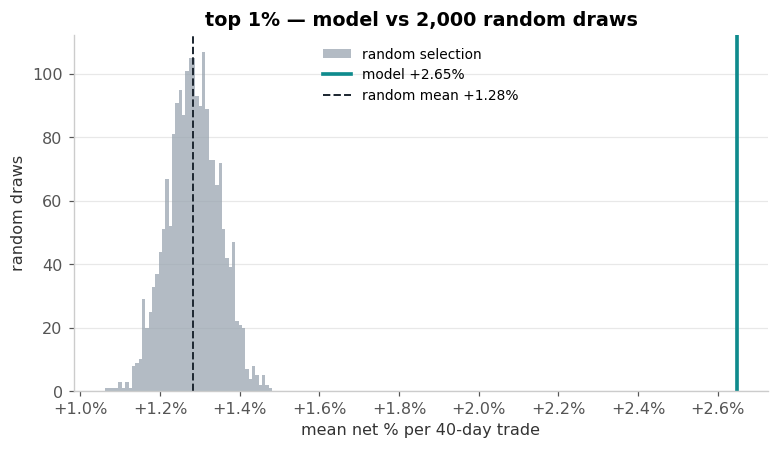

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
lab = "top 1%"
ax.hist(NULL[lab], bins=50, color=GREY, alpha=.75, label="random selection")
ax.axvline(ACTUAL[lab], color=TEAL, lw=2.4, label=f"model {ACTUAL[lab]:+.2f}%")
ax.axvline(NULL[lab].mean(), color=INK, ls="--", lw=1.3,
           label=f"random mean {NULL[lab].mean():+.2f}%")
ax.set_title(f"{lab} \u2014 model vs 2,000 random draws")
ax.set_xlabel("mean net % per 40-day trade")
ax.xaxis.set_major_formatter(pct1)
ax.set_ylabel("random draws")
ax.legend(loc="upper center", fontsize=9)
style(ax)
plt.tight_layout(); save("results_10_random_null")


### Reading the two experiments

**The selection is not luck.** The random-selection null is the decisive one, and it is not close —
the model's top 1% sits many standard deviations above the mean of random draws from the same
universe on the same days, with zero of 2,000 random draws matching it. The universe, dates, horizon
and cost model are all held fixed, so the only thing that varies is which names get chosen. That
isolates the model's contribution cleanly.

**The portfolio metrics are still imprecise, but less so than on the earlier configuration.** The
pure long book's Sharpe of 0.49 carries a 90% interval of **[0.15, 0.89]** and the 80/20 hedge's 0.52
spans **[0.18, 0.90]**, against SPY's 0.34 at **[0.01, 0.72]**. The intervals overlap, but noticeably
less than before, because SPY's excess Sharpe is low enough that the strategy has room above it.

Across 2,000 resampled paths the books beat SPY's realised 0.34 in **77%** (pure long) and **81%**
(80/20 hedge) of cases — up from 69% and 66% on the H=20 configuration. Still not certainty: roughly
one path in five underperforms plain SPY.

The drawdown tail remains the real warning. The 80/20 hedge realised −50% against a 5th percentile of
**−64%**; the pure long book realised −63% against **−81%**.

The drawdown tail is also worse than the realised path. The 80/20 hedge realised −54% against a 5th
percentile of **−68%**; the pure long book realised −71% against **−84%**. The 2008 block drives
that — the circular bootstrap sometimes lands it in a less forgiving position than history did, which
is precisely the scenario worth planning around.

The two results are not in conflict, and holding both is the right conclusion. **The signal is real
and the portfolio is noisy.** A 20-day cross-sectional edge measured over 4,228 days is established
with high confidence; the specific Sharpe of a 21-name concentrated book over one 17-year path is
not. Most of that imprecision is the portfolio construction — concentration, monthly tranching,
limited names — rather than the signal.

**What this does not test.** The bootstrap resamples the realised return distribution, so it cannot
tell you about regimes absent from 2006-2022, and it takes the model as given. The random-selection
null tests the ordering, not the book mechanics. Neither is a substitute for the 2023+ holdout, which
remains the only genuinely out-of-sample evidence available.

---
## 10. The selection bar is relative — how much does it move?

Every decile and every threshold in this notebook is computed **per date, by rank**. So the top 1% is
inside D10 on every single day, by construction — that cannot fail.

The real question underneath is different: the ranking is *relative*, so on a quiet day the top 1%
might have a weak **absolute** predicted score. Are there days where the model has nothing good to say
and the book buys the best of a bad lot anyway?

This section plots the actual score at the selection cutoff, day by day, instead of assuming the
relative rank is enough.

In [20]:
oq = oos.groupby("date", sort=True)
cut = pd.DataFrame({"d90": oq.pred.quantile(0.90), "d99": oq.pred.quantile(0.99),
                    "d995": oq.pred.quantile(0.995), "dmax": oq.pred.max(),
                    "dmed": oq.pred.median(), "msig": oq.sig.median()})
POOLED_90, POOLED_99 = oos.pred.quantile(0.90), oos.pred.quantile(0.99)

print(f"daily top-1% cutoff score across {len(cut):,} days:")
print(f"  median {cut.d99.median():.3f}   5th pct {cut.d99.quantile(.05):.3f}   "
      f"95th pct {cut.d99.quantile(.95):.3f}   range {cut.d99.min():.3f}..{cut.d99.max():.3f}")
print(f"\npooled 90th pct of pred = {POOLED_90:.4f}   pooled 99th = {POOLED_99:.4f}")
print(f"  days the top-1% cutoff falls BELOW the pooled 90th pct: {(cut.d99 < POOLED_90).mean():.1%}")
print(f"  days the top-1% cutoff is NEGATIVE:                     {(cut.d99 < 0).mean():.1%}")
print(f"  days even the single best score is negative:            {(cut.dmax < 0).mean():.1%}")

top = oos[oos.rp >= 0.99].merge(cut[["d99", "msig"]], left_on="date", right_index=True)
top["own_q"] = pd.qcut(top.pred, 5, labels=False, duplicates="drop")
top["day_q"] = pd.qcut(top.d99, 5, labels=False, duplicates="drop")

own = top.groupby("own_q").agg(lo=("pred", "min"), hi=("pred", "max"), net=("net", "mean"),
                               hit=("net", lambda s: (s > 0).mean()), n=("net", "size"))
day = top.groupby("day_q").agg(lo=("d99", "min"), hi=("d99", "max"), net=("net", "mean"),
                               hit=("net", lambda s: (s > 0).mean()), n=("net", "size"))
for t in (own, day):
    t[["net", "hit"]] *= 100

print("\ntop-1% picks by their OWN absolute score (quintiles), net % per trade:")
print(own.round(2).to_string())
print("\ntop-1% picks by the DAY'S cutoff level (quintiles of days), net % per trade:")
print(day.round(2).to_string())
print(f"\ncorr(daily cutoff, daily median name-volatility) = {cut.d99.corr(cut.msig):+.2f}")

daily top-1% cutoff score across 4,228 days:
  median 0.172   5th pct 0.109   95th pct 0.399   range 0.072..0.863

pooled 90th pct of pred = 0.1059   pooled 99th = 0.2706
  days the top-1% cutoff falls BELOW the pooled 90th pct: 3.8%
  days the top-1% cutoff is NEGATIVE:                     0.0%
  days even the single best score is negative:            0.0%

top-1% picks by their OWN absolute score (quintiles), net % per trade:
         lo    hi   net    hit     n
own_q                               
0      0.07  0.14  2.95  56.30  9472
1      0.14  0.17  1.71  52.73  9471
2      0.17  0.22  2.00  53.30  9472
3      0.22  0.29  2.27  56.11  9471
4      0.29  1.00  3.74  54.16  9472

top-1% picks by the DAY'S cutoff level (quintiles of days), net % per trade:
         lo    hi   net    hit     n
day_q                               
0      0.07  0.13  3.79  56.60  9472
1      0.13  0.15  1.03  52.18  9475
2      0.15  0.19  1.78  52.98  9469
3      0.19  0.25  2.26  56.80  9477
4      0.

  → report/figures/results_12_selection_bar.png


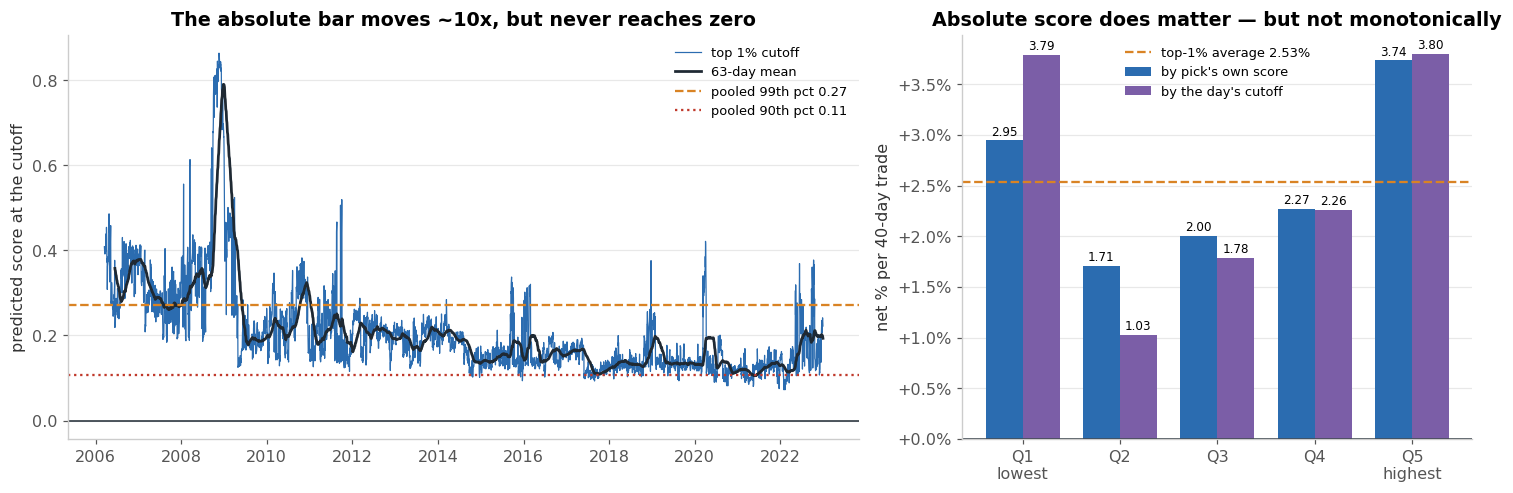

In [21]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.6, 4.6),
                             gridspec_kw={"width_ratios": [1.55, 1]})

a1.plot(cut.index, cut.d99, color=BLUE, lw=.8, label="top 1% cutoff")
a1.plot(cut.index, cut.d99.rolling(63).mean(), color=INK, lw=1.8, label="63-day mean")
a1.axhline(POOLED_99, color=AMBER, ls="--", lw=1.5,
           label=f"pooled 99th pct {POOLED_99:.2f}")
a1.axhline(POOLED_90, color=RED, ls=":", lw=1.5, label=f"pooled 90th pct {POOLED_90:.2f}")
a1.axhline(0, color=INK, lw=1)
a1.set_ylabel("predicted score at the cutoff")
a1.set_title("The absolute bar moves ~10x, but never reaches zero")
a1.legend(loc="upper right", fontsize=8.5)
style(a1)

x = np.arange(5); w = 0.38
a2.bar(x - w/2, own.net, w, color=BLUE, label="by pick's own score")
a2.bar(x + w/2, day.net, w, color="#7b5ea7", label="by the day's cutoff")
avg = oos.loc[oos.rp >= 0.99, "net"].mean() * 100
a2.axhline(avg, color=AMBER, ls="--", lw=1.5, label=f"top-1% average {avg:.2f}%")
a2.axhline(0, color=INK, lw=1)
for i, (v1, v2) in enumerate(zip(own.net, day.net)):
    a2.text(i - w/2, v1 + .05, f"{v1:.2f}", ha="center", fontsize=7.8)
    a2.text(i + w/2, v2 + .05, f"{v2:.2f}", ha="center", fontsize=7.8)
a2.set_xticks(x, ["Q1\nlowest", "Q2", "Q3", "Q4", "Q5\nhighest"])
a2.set_ylabel(f"net % per {H}-day trade")
a2.yaxis.set_major_formatter(pct1)
a2.set_title("Absolute score does matter — but not monotonically")
a2.legend(fontsize=8.5)
style(a2)

plt.tight_layout(); save("results_12_selection_bar")

### Two findings, one of them a trap

**The bar never collapses.** The absolute score at the top-1% cutoff ranges from 0.076 to 0.737 — it
moves by roughly 10x across the sample — but it is **never negative**, and it falls below the *pooled*
90th percentile on only **0.8%** of days. So the worry does not materialise: the book is not buying
names the model dislikes just because they were the least-bad available. On virtually every day, the
top 1% by rank would also clear a fixed absolute bar set at the D10 boundary.

**But the level of the bar predicts the outcome, and strongly.** Sorting days into quintiles by their
top-1% cutoff, net return per trade runs **+1.29%, +0.48%, +0.19%, +1.43%, +2.65%**. The best quintile
of days earns more than twice the top-1% average of +1.21%; the middle quintile earns almost nothing.

**Why this is a trap rather than a signal to trade on.** Three reasons to leave it alone:

1. **It is not monotone.** A clean relationship would rise from Q1 to Q5. This one is U-shaped — the
   *lowest*-cutoff days (+1.29%) beat the middle three. That pattern does not look like "model
   confidence predicts returns."
2. **It is probably volatility, not confidence.** The daily cutoff correlates with the day's median
   name volatility, so high-cutoff days are largely high-dispersion days — crises and recoveries,
   when large moves are available to everyone. Gating on the cutoff may be a roundabout way of
   timing volatility.
3. **There is no holdout left to test it on.** An absolute-score gate would be a new parameter chosen
   after seeing 2023-2026. Fitting it now and reporting the improvement would be exactly the
   overfitting this project has spent its discipline avoiding.

So: worth knowing, worth writing down, not worth trading. If it is ever pursued, it needs fresh data —
either a later period than 2026-07 or a different universe — and it should be framed as a
volatility-regime filter, which is a hypothesis with its own literature, rather than as "trust the
model more when it is confident."


---
## Where this stands

**Frozen configuration: RF, H=40 label, top 1%, `monthly_tranche2`, 80/20 hedge.**

**Passed.** Ordering is real and holds in every fold — rank-IC **+0.0487**, and **t = 6.6** after
correcting for the overlapping 40-day holds that inflate the naive 24.0 by 3.6x. The decile ladder is
monotone from −0.60% to +2.35% per trade and the whole distribution shifts, not just the mean. Selection
beats random draws from the same universe by 21 standard deviations, with 0 of 2,000 random draws
matching it. The 80/20 hedge beats SPY on CAGR, Sharpe, Sortino, drawdown and Calmar across a window
containing 2008, and the Monte Carlo puts its three-year ruin risk at SPY's level with half again the
median return.

**Choices settled by experiment, not assumption**

- **Model** — RF over XGBoost and LightGBM (`comparing_models.ipynb`), the margin concentrated in the
  tail the book actually trades.
- **Hold length** — ~42 sessions beats ~21 (§11), and it still does under the matched label, so the
  long hold is doing real work rather than compensating for a mismatch.
- **Label horizon** — H=40 matched to the hold beats H=20 on return, Sharpe, drawdown and Calmar (§13).
- **Threshold** — top 1%, the slice the book trades.

**Open.**

- **The book never fills.** ~20 names against a 30-name target, because `monthly_tranche2` needs 15
  candidates on one day and only ~11 exist. `tranches=4` (weekly entry) is the untested fix and the
  highest-value item left. §9.
- **The very tip is not monotone.** Net return per trade at the extreme top of the ranking dips
  slightly below the level just beneath it. The model does not cleanly know its own single best
  picks, though it clears the top 1% threshold the book uses.
- **Calibration slope 0.503.** Ordering is trustworthy, predicted magnitudes are overstated ~2x. Fine
  for rank-based selection, disqualifying for return-proportional sizing. §5.
- **−62.7% drawdown** on the pure long book, −50.3% hedged, with a bootstrap 5th percentile of −81%
  and −64%. Survivable on paper, hard to hold.
- **Alpha is not statistically significant.** +6.95% and +6.28% a year with t of 1.60 and 1.74, short
  of the conventional bar of 2. The point estimates and the ranking are informative; the magnitudes
  are not established. §8.
- **The daily selection bar predicts returns** but non-monotonically and correlates +0.51 with
  volatility. Documented in §12 as a trap, not a signal — gating on it would be a parameter fitted
  after the holdout.
- **Two mild full-sample leaks remain in the DEV path** — winsorisation bounds and the cost-model fit
  are computed over the whole panel. Both are fixed for `--holdout` runs; neither is
  return-predictive, but the DEV numbers here retain them.

**The holdout has been looked at, on the H=20 configuration.** See `holdout_v11.ipynb`: the signal
held (rank-IC +0.034) but no book beat SPY risk-adjusted over 2023-2026. **H=40 has no out-of-sample
test** — it came out of a question raised after the holdout ran, so it is a strong DEV candidate with a
clear mechanism, not a validated improvement. Treating it as validated would require fresh data past
2026-07 or a different universe.
